# CNN Deconv Topological studies

Study the performance of NEXT classical toplogocal method using data previously deconvoluted bu Martin's CNN

25/11/24 Santiago

In [69]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [70]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [71]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [72]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [73]:
import nana.topo.evtfun    as evtfun
import nana.topo.graphfun  as graphfun

In [74]:
import hipy.utils        as ut

#import hipy.histos       as histos
import hipy.pltext       as pltext
#import hipy.profile      as prof
#from invisible_cities.io.dst_io import load_dst, load_dsts
from hipy.styles import style
style()

## Load data


In [75]:
datafilename = 'dataset_15607_DEP_deco.h5'
mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
datapath     = '/mnt/netapp1/Store_next_data/NEXT100/deco_seg/'

In [76]:
ifilename = datapath + datafilename
print(f'loading {ifilename}')
data     =  pd.read_hdf(ifilename, 'DATASET/Voxels');
bin_info =  pd.read_hdf(ifilename, 'DATASET/BinsInfo');
bin_widths  = evtfun.get_bin_widths(bin_info)

loading /mnt/netapp1/Store_next_data/NEXT100/deco_seg/dataset_15607_DEP_deco.h5


In [77]:
data

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred
0,0,-1,24,44,77,0.000237,-1,0.087309,0
1,0,-1,25,45,77,0.000301,-1,0.076018,0
2,0,-1,25,45,78,0.000468,-1,0.084663,0
3,0,-1,25,46,77,0.000253,-1,0.067720,0
4,0,-1,25,46,78,0.000197,-1,0.069409,0
...,...,...,...,...,...,...,...,...,...
6805395,10777,-1,27,15,23,0.000210,-1,0.093303,0
6805396,10777,-1,27,21,23,0.000190,-1,0.087002,0
6805397,10777,-1,27,23,9,0.000216,-1,0.069199,0
6805398,10777,-1,27,24,9,0.000611,-1,0.083242,0


### Get the deconv data (share the energy)

## Display an event

In [100]:
ievent   = 22

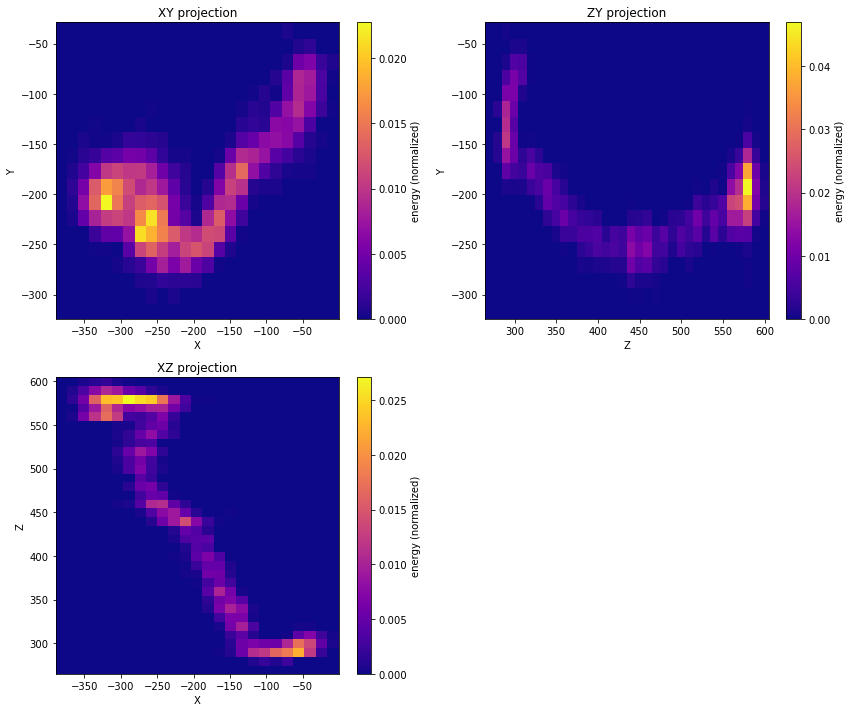

In [101]:
evt   = data.groupby('dataset_id').get_group(ievent)
coors = evtfun.get_coors(evt, bin_info)
ene   = evt.energy.values 
evtfun.event_display(coors, bins, ene = ene);


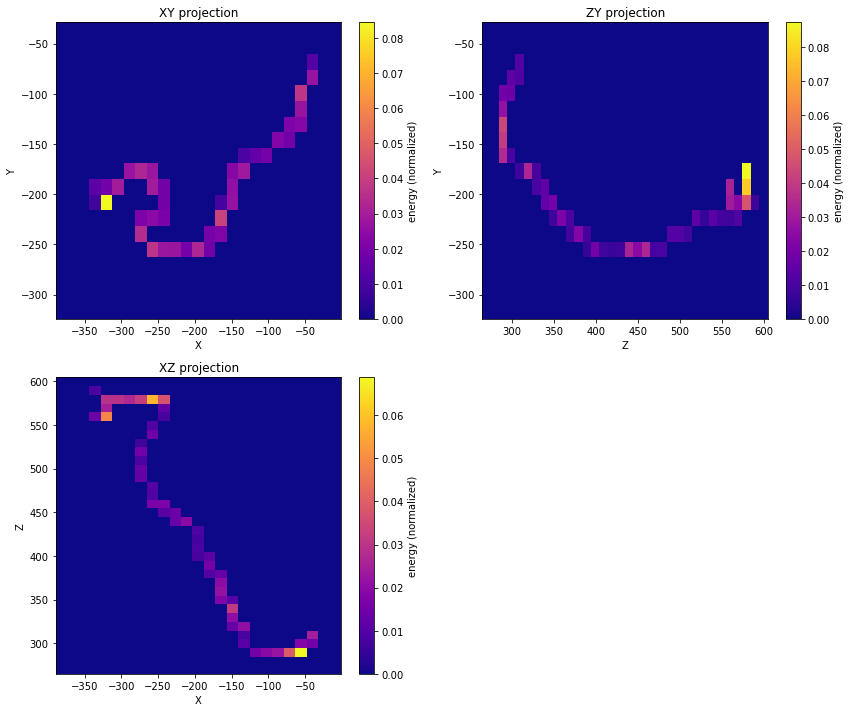

In [102]:
evtdeco   = evtfun.get_deconvoluted_event(evt)
coorsdeco = evtfun.get_coors(evtdeco, bin_info)
enedeco   = evtdeco.enecor.values
evtfun.event_display(coorsdeco, bins = bins, ene = enedeco);

In [103]:
evtdeco

,dataset_id,binclass,xbin,ybin,zbin,energy,decolabel,decoscore,decopred,enecor
14355,22,-1,10,18,59,0.001888,-1,0.585994,1,0.008409
14357,22,-1,10,19,56,0.003089,-1,0.558911,1,0.013757
14380,22,-1,11,18,56,0.006774,-1,0.711397,1,0.030168
14381,22,-1,11,18,57,0.005558,-1,0.553650,1,0.024752
14382,22,-1,11,18,58,0.006609,-1,0.608346,1,0.029432
...,...,...,...,...,...,...,...,...,...,...
14988,22,-1,28,25,29,0.004264,-1,0.632079,1,0.018989
14989,22,-1,28,25,30,0.004077,-1,0.582997,1,0.018160
15012,22,-1,29,26,30,0.003403,-1,0.600670,1,0.015158
15013,22,-1,29,26,31,0.002717,-1,0.582509,1,0.012102


In [105]:
for zbin, zslice in evt.groupby('zbin'):
    ene    = zslice.energy.sum() 
    enecor = evtdeco[evtdeco.zbin == zbin].enecor.sum()
    eneref = evtdeco[evt.zbin == zbin].energy.sum()
    print(zbin, ene, eneref, eneref/ene, enecor)
print(evtdeco.energy.sum())

28 0.006222753 0.0 0.0 0.0
29 0.10151312 0.037072644 0.36520052 0.1651085025990298
30 0.07159804 0.009847895 0.1375442 0.04385905853673902
31 0.022700613 0.0072732205 0.32039753 0.03239236240035148
32 0.020449823 0.00758155 0.37073916 0.03376555539903666
33 0.01635855 0.0045976504 0.28105488 0.020476316205365323
34 0.026145311 0.0070407363 0.2692925 0.03135696069185151
35 0.018678525 0.006329723 0.33887702 0.02819035918132356
36 0.021210331 0.0048783943 0.23000085 0.021726650838118845
37 0.011424164 0.0044832453 0.3924353 0.019966797371324348
38 0.01362483 0.005189624 0.3808946 0.023112758995755066
39 0.013351823 0.0036050102 0.27000135 0.016055446408492456
40 0.015525866 0.0044225045 0.28484753 0.019696277416295274
41 0.008139493 0.0019806137 0.24333379 0.008820956090666188
42 0.012638886 0.001669212 0.13206954 0.007434082667088103
43 0.011075133 0.0019087842 0.17234863 0.00850105263263554
44 0.040015183 0.0073563103 0.18383798 0.032762415145798425
45 0.027716063 0.0055784853 0.201272

In [98]:
coorsdeco = evtfun.get_coors(evtdeco, bin_info)
enedeco   = evtdeco.enecor.values
evtfun.event_display(coorsdeco, bins = bins, ene = enedeco);

AttributeError: 'DataFrame' object has no attribute 'enecor'

## Display graph

In [62]:
graph                      = graphfun.convert_to_graph(coorsdeco, bins, enedeco, nsides = 3)
componentes, longest_graph = graphfun.graph_connectivity(graph)
_, longest_graph2          = graphfun.graph_connectivity(longest_graph)

[(-1, -1, -1), (-1, -1, 0), (-1, -1, 1), (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), (-1, 1, -1), (-1, 1, 0), (-1, 1, 1), (0, -1, -1), (0, -1, 0), (0, -1, 1), (0, 0, -1), (0, 0, 0), (0, 0, 1), (0, 1, -1), (0, 1, 0), (0, 1, 1), (1, -1, -1), (1, -1, 0), (1, -1, 1), (1, 0, -1), (1, 0, 0), (1, 0, 1), (1, 1, -1), (1, 1, 0), (1, 1, 1)]
Is graph conected?  True
Number of components: 1
Component 1: {(10, 4, 17), (13, 4, 13), (9, 8, 31), (9, 4, 19), (16, 9, 4), (19, 11, 2), (21, 13, 2), (8, 9, 31), (22, 15, 3), (16, 9, 5), (14, 7, 8), (10, 4, 18), (21, 12, 2), (16, 10, 3), (3, 8, 29), (7, 9, 31), (15, 9, 6), (13, 5, 11), (8, 6, 28), (7, 6, 26), (8, 4, 19), (15, 9, 5), (17, 10, 2), (15, 8, 6), (5, 8, 31), (7, 5, 24), (4, 8, 29), (15, 7, 7), (22, 16, 4), (15, 8, 7), (3, 7, 32), (4, 7, 30), (7, 6, 25), (9, 7, 31), (13, 5, 12), (14, 5, 10), (18, 10, 2), (6, 9, 31), (4, 7, 31), (14, 5, 11), (9, 6, 29), (7, 5, 23), (14, 6, 10), (8, 6, 27), (15, 7, 8), (20, 12, 2), (22, 15, 4), (9, 6, 30), (7, 5, 22), (12, 4

extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 8, 29)
extremes distance: 42 , extrenes nodes: (22, 16, 4) (3, 7, 32)


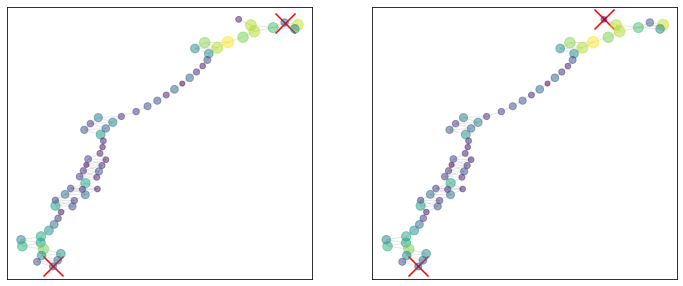

In [63]:
cv = pltext.canvas(2, 2)
cv(1)
u, v, dist = graphfun.graph_extremes(graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(graph, (u, v))
cv(2)
u, v, dist = graphfun.graph_extremes(longest_graph)
print('extremes distance:', dist, ", extrenes nodes:", u, v)
graphfun.display_graph(longest_graph, (u, v))

In [40]:
graph.nodes

NodeView(((3, 7, 32), (4, 7, 31), (3, 8, 29), (4, 7, 29), (4, 7, 30), (4, 8, 29), (5, 8, 31), (6, 9, 31), (7, 9, 31), (7, 5, 22), (7, 5, 23), (8, 4, 21), (7, 5, 24), (7, 6, 25), (7, 6, 26), (8, 6, 27), (8, 8, 31), (8, 9, 31), (8, 4, 19), (8, 4, 20), (9, 4, 18), (9, 4, 19), (8, 6, 28), (9, 6, 29), (9, 7, 31), (9, 8, 31), (10, 4, 17), (10, 4, 18), (9, 6, 30), (11, 4, 17), (12, 4, 16), (12, 4, 13), (12, 4, 14), (13, 4, 12), (13, 4, 13), (13, 5, 12), (12, 4, 15), (13, 5, 11), (14, 5, 11), (14, 5, 10), (14, 6, 10), (14, 6, 9), (14, 6, 8), (14, 7, 8), (15, 7, 7), (15, 7, 8), (15, 8, 7), (15, 8, 6), (15, 9, 5), (15, 9, 6), (16, 9, 5), (16, 9, 4), (16, 10, 3), (17, 10, 2), (18, 10, 2), (19, 11, 2), (20, 11, 2), (20, 12, 2), (21, 12, 2), (21, 13, 2), (21, 14, 2), (21, 14, 3), (22, 15, 3), (22, 15, 4), (22, 16, 4)))